In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/titanic_toy.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [9]:

df.isnull().sum() 

Age         177
Fare         45
Survived      0
dtype: int64

In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [8]:
X_test.tail()

,Age,Fare,Age_imputed
433,17.0,7.1250,17.0
773,NaN,7.2250,NaN
25,38.0,31.3875,38.0
84,17.0,10.5000,17.0
10,4.0,16.7000,4.0


In [12]:
# Random imputation for X_train
n_missing_train = X_train['Age_imputed'].isnull().sum()

X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = \
    X_train['Age'].dropna().sample(n_missing_train).values


# Random imputation for X_test
n_missing_test = X_test['Age_imputed'].isnull().sum()

X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = \
    X_train['Age'].dropna().sample(n_missing_test).values

In [14]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([30. , 28. , 32. ,  2. , 25. , 26. , 36. , 28.5, 50. , 23. , 49. ,
       70. , 39. , 28. , 48. , 26. , 24. , 61. ,  7. , 32. , 31. , 16. ,
       35. , 54. , 45. , 25. , 11. , 21. , 28. , 23. , 12. , 35. , 22. ,
       34. , 18. , 18. , 32. , 44. , 16. , 49. , 31. , 42. , 34. , 19. ,
       26. , 14. , 22. , 32. , 21. , 38. ,  2. , 28. , 34. , 53. ,  9. ,
       22. , 31. , 51. , 25. , 17. , 33. , 16. , 28. , 24. , 43. , 25. ,
       24. , 28. , 14. , 18. , 28. ,  7. , 23. , 25. , 35. ,  9. , 34. ,
       70.5, 24. , 45. , 30. , 18. , 24. , 14. , 22. , 27. , 26. , 20. ,
       34. , 42. , 16. , 25. , 32. , 44. , 28. , 21. ,  5. , 45. , 22. ,
       15. , 39. , 28. , 34. ,  4. , 33. , 21. , 59. , 26. , 55.5, 19. ,
       45. , 26. , 51. ,  4. , 57. , 24. , 33. , 18. , 62. , 25. , 42. ,
       41. , 42. , 26. , 21. , 21. , 30. , 33. , 41. , 58. , 20. , 19. ,
       47. , 54. , 24. , 25. , 30. , 27. , 20. , 37. ])

In [16]:
X_train["Age_imputed"].isnull().sum()

0

C:\Users\abbur\AppData\Local\Temp\ipykernel_29748\2642582470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\abbur\AppData\Local\Temp\ipykernel_29748\2642582470.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[

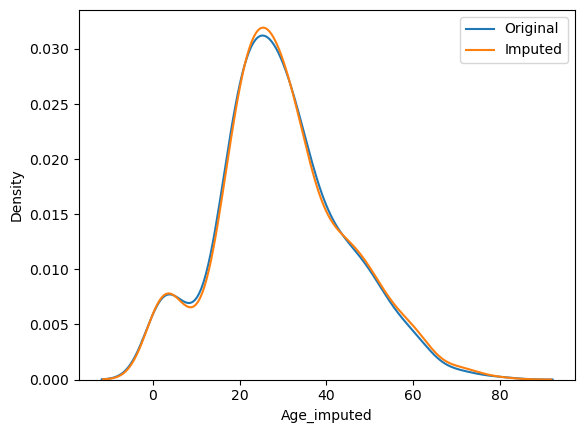

In [18]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [19]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  210.2517072477438
Variance after random imputation:  217.41900842222506


In [20]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2761.031435,75.481375,56.512398
Age,75.481375,210.251707,210.251707
Age_imputed,56.512398,210.251707,217.419008


<Axes: >

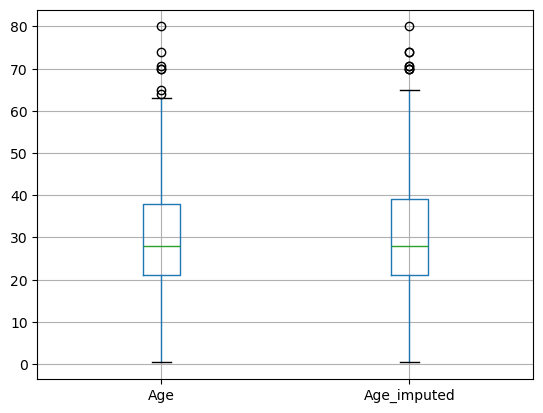

In [21]:

X_train[['Age', 'Age_imputed']].boxplot()

In [25]:
for index, observation in X_train.iterrows():
    if pd.isnull(observation['Age']):
        
        if pd.isnull(observation['Fare']):
            random_state = 42
        else:
            random_state = int(observation['Fare'])
        
        sampled_value = X_train['Age'].dropna().sample(
            1,
            random_state=random_state
        )
        
        X_train.loc[index, 'Age_imputed'] = sampled_value.iloc[0]